## Imports and setup

In [33]:
from marvin.tools import Maps, Image
from marvin.utils.dap.bpt import kewley_sf_sii, kewley_agn_sii
from marvin import config
from marvin.utils.general.general import get_drpall_table
import marvin.utils.plot.map as mapplot

import os
import csv
import json
import numpy as np
rng = np.random.default_rng(seed=42)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from astropy.table import Table
from tqdm import tqdm

In [4]:
config.setRelease('DR17')
drpall_df = get_drpall_table()
plateifu_ids = np.array(drpall_df['plateifu'], dtype='str')

## Parameter values for the QA variants

Default is SN=3, LIER ratio = 0.5. Variants vary one parameter at a time:
the SN=2 cut as an SNR robustness check, and two alternative LIER ratios as a
boundary-sensitivity check. The bins variant was dropped — manual inspection
showed that nearby bins are correlated by MaNGA's PSF and don't produce
meaningfully different classifications. Variant names encode parameters so
column names in the CSV are self-documenting.

In [6]:
# SNR cutoffs
SN_DEFAULT = 3.0
SN_ALT     = 2.0

# LIER ratio cutoffs
LIER_RATIO_DEFAULT = 0.5
LIER_RATIO_04      = 0.4
LIER_RATIO_06      = 0.6

# Radial bins (one value now — no bins variant)
RADIAL_BINS = 10

# Variant list: baseline + one-parameter-off-at-a-time alternatives.
# Exactly one variant must have 'baseline': True. Add variants by appending here.
VARIANTS = [
    {'name': 'sn3_lier05', 'sn_min': SN_DEFAULT, 'lier_frac': LIER_RATIO_DEFAULT, 'n_bins': RADIAL_BINS, 'baseline': True},
    {'name': 'sn2_lier05', 'sn_min': SN_ALT,     'lier_frac': LIER_RATIO_DEFAULT, 'n_bins': RADIAL_BINS},
    {'name': 'sn3_lier04', 'sn_min': SN_DEFAULT, 'lier_frac': LIER_RATIO_04,      'n_bins': RADIAL_BINS},
    {'name': 'sn3_lier06', 'sn_min': SN_DEFAULT, 'lier_frac': LIER_RATIO_06,      'n_bins': RADIAL_BINS},
]

# Functions

## Helpers

In [8]:
def sn(m):
    """S/N per spaxel from a Marvin Map using its ivar attribute."""
    return np.abs(m.value) * np.sqrt(m.ivar)


def _circular_mask(classification, fwhm_arcsec, spaxel_scale=0.5):
    """Circular aperture of radius (FWHM/spaxel_scale + 1) centered on the image."""
    ny, nx = classification.shape
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0

    radius_pix = (fwhm_arcsec / spaxel_scale) + 1

    yy, xx = np.ogrid[:ny, :nx]
    dist = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    return dist <= radius_pix


def _re_mask(re, re_step, re_map_arr):
    """Annular Re shell from (re - re_step) to re."""
    r2 = re - re_step
    if r2 == 0:
        return re_map_arr < re
    return (re_map_arr < re) & (re_map_arr > r2)


def _extract_data(maps):
    """Pull all arrays the pipeline needs from a Maps object. Called once per galaxy."""
    ha   = maps['emline_gflux_ha_6564']
    hb   = maps['emline_gflux_hb_4862']
    oiii = maps['emline_gflux_oiii_5008']
    s18  = maps['emline_gflux_sii_6718']
    s32  = maps['emline_gflux_sii_6732']
    ew_map = maps['emline_gew_ha_6564']

    return {
        'ha_v':         ha.value,
        'hb_v':         hb.value,
        'oiii_v':       oiii.value,
        's18_v':        s18.value,
        's32_v':        s32.value,
        'sn_ha':        sn(ha),
        'sn_hb':        sn(hb),
        'sn_oiii':      sn(oiii),
        'sn_s18':       sn(s18),
        'sn_s32':       sn(s32),
        'in_footprint': maps['spx_mflux'].value > 0,
        'ew_v':         ew_map.value,
        'ew_mask':      ew_map.mask,
        're_map':       np.array(maps['spx_ellcoo_r_re']),
        'psf':          float(maps.header['RFWHM']),
    }

## Resolved BPT classifier

In [10]:
def classify_bpt_sii(data, sn_min=2.0):
    """
    Resolved [SII] BPT classification per spaxel (Kewley+2001 / Kewley+2006).

    Codes:
        0 = outside galaxy (background)
        1 = inside galaxy, S/N too low to classify
        2 = star-forming
        3 = LIER
        4 = Seyfert
    """
    sn_mask = ((data['sn_ha']   > sn_min) &
               (data['sn_hb']   > sn_min) &
               (data['sn_oiii'] > sn_min) &
               (data['sn_s18']  > sn_min) &
               (data['sn_s32']  > sn_min))

    sii_sum = data['s18_v'] + data['s32_v']
    with np.errstate(divide='ignore', invalid='ignore'):
        x = np.log10(sii_sum / data['ha_v'])
        y = np.log10(data['oiii_v'] / data['hb_v'])

    above_sf  = y > kewley_sf_sii(x)
    above_agn = y > kewley_agn_sii(x)

    classification = np.zeros_like(data['ha_v'], dtype=int)
    classification[data['in_footprint']] = 1
    classification[sn_mask & ~above_sf] = 2
    classification[sn_mask &  above_sf & ~above_agn] = 3
    classification[sn_mask &  above_sf &  above_agn] = 4
    return classification, sn_mask

## Line-less check

In [12]:
def mean_ew_within_re(ew_values, ew_mask, re_map_arr, aperture_re=1.0):
    """Mean EW(Halpha) within `aperture_re` * Re."""
    aperture = _re_mask(aperture_re, aperture_re, re_map_arr)
    good = aperture & (ew_mask == 0) & np.isfinite(ew_values)
    if not np.any(good):
        return np.nan
    return float(np.mean(ew_values[good]))

## Region counting and classification

In [14]:
def count_classes(classification, fwhm_arcsec=None, aperture=None):
    """Count spaxels of each class within a mask. Defaults to 1-PSF circular mask."""
    if aperture is None:
        aperture = _circular_mask(classification, fwhm_arcsec)
    return {cls: int(np.sum((classification == cls) & aperture))
            for cls in (1, 2, 3, 4)}


def classify_region(counts, max_bad_frac=0.5, sy_frac=0.30, lier_frac=0.5):
    """Assign a class to a region from its spaxel counts.

    Setting max_bad_frac higher relaxes the bad-SNR gate; the outer-region
    classification uses 0.8 so noisy outer regions still get classified.
    """
    n_bad  = counts[1]
    n_sf   = counts[2]
    n_lier = counts[3]
    n_sy   = counts[4]

    n_good   = n_sf + n_lier + n_sy
    n_galaxy = n_bad + n_good

    if n_galaxy == 0:
        return 'empty'
    if n_bad / n_galaxy > max_bad_frac:
        return 'Bad_SNR (Lineless)'
    if n_good == 0:
        return 'Bad_SNR (Lineless)'
    if n_sy / n_good > sy_frac:
        return 'Sy'
    if n_lier / (n_lier + n_sf) > lier_frac:
        return 'LIER'
    return 'SF'

## Radial profile builder

In [16]:
def classify_radial_profile(classification, re_map_arr, sn_mask,
                            n_bins, lier_frac, min_good_frac=0.20):
    """Walk outward in equal-width Re annuli, classify each one."""
    try:
        r_max = np.max(re_map_arr[sn_mask])
    except ValueError:
        return []

    re_step = r_max / n_bins
    r = 0
    annuli = []
    while r < r_max:
        r = r + re_step
        re_mask = _re_mask(r, re_step, re_map_arr)
        counts  = count_classes(classification, aperture=re_mask)
        label   = classify_region(counts, max_bad_frac=0.50, lier_frac=lier_frac)
        annuli.append({
            'Radius (Re)': r,
            'Counts':      counts,
            'Class':       label,
        })
        if label == 'empty':
            break
    return annuli

## Merger flag tables

In [18]:
table = Table.read('MaNGA GZD v1.0.1.fits', format='fits')
df_table = table.to_pandas()
df_table['PLATEIFU'] = df_table['PLATEIFU'].str.decode('utf-8').str.strip()
df_table['MANGAID']  = df_table['MANGAID'].str.decode('utf-8').str.strip()
df_table = df_table[['PLATEIFU', 'MANGAID', 'merging_major-disturbance_fraction']]

table2 = Table.read('MaNGA v2.0.1.fits')
df_table2 = table2.to_pandas()
df_table2['PLATEIFU'] = df_table2['PLATEIFU'].str.decode('utf-8').str.strip()
df_table2['MANGAID']  = df_table2['MANGAID'].str.decode('utf-8').str.strip()
df_table2 = df_table2[['MANGAID', 'PLATEIFU', 't08_odd_feature_a24_merger_flag']]

In [20]:
def test_tables(gal_id):
    """Check merger flags. Returns 1 if flagged as merger, 0 otherwise."""
    try:
        mask = (df_table2['PLATEIFU'] == gal_id) | (df_table2['MANGAID'] == gal_id)
        return list(df_table2[mask]['t08_odd_feature_a24_merger_flag'])[0]
    except Exception:
        return _test_table_1(gal_id)


def _test_table_1(gal_id):
    try:
        mask = (df_table['PLATEIFU'] == gal_id) | (df_table['MANGAID'] == gal_id)
        frac = list(df_table[mask]['merging_major-disturbance_fraction'])[0]
        return 1 if frac > 0.3 else 0
    except Exception:
        return 0

## Per-variant classifier

Computes central + outer + radial classification for one parameter combination,
plus a `Has Sy Annulus` flag that fires if **any** annulus in the radial profile
is classified as Sy (catches both central Seyferts and extended-NLR cases).
Outer region uses `max_bad_frac=0.8` so noisy outskirts still produce a class.

In [22]:
def classify_one(bpt, sn_mask, re_map, psf, n_bins, lier_frac):
    """Run central + outer + radial classification for one parameter combination."""
    last_LIER_radius = np.nan

    # Central: 1-PSF circular aperture
    central_aperture = _circular_mask(bpt, psf)
    central_counts   = count_classes(bpt, aperture=central_aperture)
    central_class    = classify_region(central_counts, lier_frac=lier_frac)

    # Outer: everything outside the central aperture; relaxed SNR gate
    outer_aperture = ~central_aperture
    outer_counts   = count_classes(bpt, aperture=outer_aperture)
    outer_class    = classify_region(outer_counts,
                                     max_bad_frac=0.8, lier_frac=lier_frac)

    if central_class == 'Bad_SNR (Lineless)':
        return {
            'Classification':        central_class,
            'Central Class':         central_class,
            'Outer Class':           outer_class,
            'Has Sy Annulus':        False,
            'Last LIER Radius (Re)': last_LIER_radius,
            'Radial Profile':        None,
        }

    profile = classify_radial_profile(bpt, re_map, sn_mask,
                                      n_bins=n_bins, lier_frac=lier_frac)

    # Sy-annulus flag: any annulus classified as Sy
    has_sy_annulus = any(ann['Class'] == 'Sy' for ann in profile)

    good_classes = {'SF', 'LIER', 'Sy'}
    good_annuli  = [ann for ann in profile if ann['Class'] in good_classes]
    n_good = len(good_annuli)

    if n_good == 0:
        if central_class == 'LIER':
            gal_class = 'eLIER'
            last_LIER_radius = -9999
        else:
            gal_class = central_class
    else:
        if central_class == 'Sy':
            gal_class = 'Sy'
        elif central_class == 'LIER':
            gal_class = 'eLIER'
            for ann in good_annuli:
                if ann['Class'] == 'LIER':
                    last_LIER_radius = ann['Radius (Re)']
                elif ann['Class'] == 'SF':
                    gal_class = 'cLIER'
        else:
            last_good = good_annuli[-1]
            if last_good['Class'] == 'LIER':
                last_LIER_radius = last_good['Radius (Re)']
                gal_class = 'outLIER'
            else:
                gal_class = 'SF'

    return {
        'Classification':        gal_class,
        'Central Class':         central_class,
        'Outer Class':           outer_class,
        'Has Sy Annulus':        has_sy_annulus,
        'Last LIER Radius (Re)': last_LIER_radius,
        'Radial Profile':        profile,
    }

## BPT figure builder

In [24]:
def plotter(plot, ax=None):
    """Render a classification map onto an Axes (or a fresh one)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    cmap = ListedColormap(['white', 'lightgray', 'royalblue', 'gold', 'crimson'])
    bounds = [-1, 0.99, 1.99, 2.99, 3.99, 4.99]
    norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

    ax.imshow(plot, cmap=cmap, origin='lower', norm=norm)
    ax.set_title('Resolved [SII] BPT')
    return ax


def _make_bpt_figure(bpt, psf, title=None):
    """Build a standalone Figure with the BPT classification and a 1-PSF contour."""
    fig, ax = plt.subplots(figsize=(6, 6))
    plotter(bpt, ax=ax)
    mask = _circular_mask(bpt, psf)
    ax.contour(mask.astype(int), levels=[0.5], colors='black', linewidths=1.5)
    if title:
        ax.set_title(title)
    plt.close(fig)
    return fig

## Main classifier — runs all variants for one galaxy

In [26]:
def classify_all_variants(plateifu, variants=VARIANTS,
                          make_plot=True, plot_sn_min=None):
    """Classify one galaxy under all parameter variants.

    Parameters
    ----------
    plateifu : str
    variants : list of dict
        Variants to run; exactly one must have 'baseline': True.
    make_plot : bool
        If True, build a standalone BPT figure with 1-PSF contour.
    plot_sn_min : float or None
        SN cutoff for the figure. If None, uses the baseline variant's SN.
        Set independently because we may want a stricter cutoff for inspection
        than we use for some of the robustness variants.

    Returns
    -------
    dict with keys:
        'plateifu', 'EW 1Re',
        'Resolved BPT'  (2D classification array, baseline params, or None),
        'BPT Figure'    (matplotlib Figure with 1-PSF contour, or None),
        'variants'      (dict keyed by variant name).
    """
    out = {
        'plateifu':     plateifu,
        'EW 1Re':       np.nan,
        'Resolved BPT': None,
        'BPT Figure':   None,
        'variants':     {},
    }

    baseline_v = next(v for v in variants if v.get('baseline'))

    # 1. Merger check (no maps loading)
    if test_tables(plateifu) == 1:
        for v in variants:
            out['variants'][v['name']] = {
                'Classification':        'Merger',
                'Central Class':         'Merger',
                'Outer Class':           'Merger',
                'Has Sy Annulus':        False,
                'Last LIER Radius (Re)': np.nan,
                'Radial Profile':        None,
            }
        return out

    # 2. Load maps once
    maps = Maps(plateifu)
    data = _extract_data(maps)

    # 3. EW within 1 Re
    ew = mean_ew_within_re(data['ew_v'], data['ew_mask'], data['re_map'],
                           aperture_re=1.0)
    out['EW 1Re'] = ew

    # 4. Cache BPT by sn_min
    bpt_cache = {}
    def get_bpt(sn_min):
        if sn_min not in bpt_cache:
            bpt_cache[sn_min] = classify_bpt_sii(data, sn_min=sn_min)
        return bpt_cache[sn_min]

    # Baseline BPT (always computed; used for the array return)
    baseline_bpt, _ = get_bpt(baseline_v['sn_min'])
    out['Resolved BPT'] = baseline_bpt
    if make_plot:
        sn_for_plot = plot_sn_min if plot_sn_min is not None else baseline_v['sn_min']
        plot_bpt, _ = get_bpt(sn_for_plot)  # cache reuse if same as baseline
        out['BPT Figure'] = _make_bpt_figure(
            plot_bpt, data['psf'],
            title=f'{plateifu} — resolved [SII] BPT (sn_min={sn_for_plot})',
        )

    # 5. Line-less check
    if np.isfinite(ew) and ew < 1.0:
        for v in variants:
            out['variants'][v['name']] = {
                'Classification':        'Lineless',
                'Central Class':         'Lineless',
                'Outer Class':           'Lineless',
                'Has Sy Annulus':        False,
                'Last LIER Radius (Re)': np.nan,
                'Radial Profile':        None,
            }
        return out

    # 6. Run each variant
    for v in variants:
        bpt, sn_mask = get_bpt(v['sn_min'])
        out['variants'][v['name']] = classify_one(
            bpt=bpt, sn_mask=sn_mask,
            re_map=data['re_map'], psf=data['psf'],
            n_bins=v['n_bins'], lier_frac=v['lier_frac'],
        )

    return out

## Batch classifier

Writes a CSV with one row per galaxy and saves BPT figures as PNGs under
`{figures_dir}/{plate}/{plateifu}.png`. The baseline radial profile is
JSON-encoded into a CSV column (Re + class only, no per-spaxel counts).
No pickle — for downstream work we'll recompute radial profiles as needed.

In [28]:
def _build_csv_columns(variants):
    cols = ['plateifu', 'ew_1re']
    for v in variants:
        n = v['name']
        cols += [f'{n}_class', f'{n}_central', f'{n}_outer',
                 f'{n}_has_sy_annulus', f'{n}_last_lier_re']
    cols += ['baseline_radial_profile', 'bpt_figure_path']
    return cols


def _strip_profile(profile):
    """Keep only Radius (Re) and Class — drop the per-spaxel counts."""
    if profile is None:
        return None
    return [{'r': a['Radius (Re)'], 'class': a['Class']} for a in profile]


def _flatten_row(plateifu, result, variants, fig_path=''):
    row = {'plateifu': plateifu, 'ew_1re': result.get('EW 1Re', np.nan)}
    for v in variants:
        n = v['name']
        vr = result['variants'].get(n, {})
        row[f'{n}_class']          = vr.get('Classification', '')
        row[f'{n}_central']        = vr.get('Central Class', '')
        row[f'{n}_outer']          = vr.get('Outer Class', '')
        row[f'{n}_has_sy_annulus'] = vr.get('Has Sy Annulus', False)
        row[f'{n}_last_lier_re']   = vr.get('Last LIER Radius (Re)', np.nan)

    baseline_v = next(v for v in variants if v.get('baseline'))
    baseline_profile = (result['variants']
                              .get(baseline_v['name'], {})
                              .get('Radial Profile'))
    stripped = _strip_profile(baseline_profile)
    row['baseline_radial_profile'] = json.dumps(stripped) if stripped else ''
    row['bpt_figure_path']         = fig_path
    return row


def batch_classify(plateifus,
                   csv_path='lier_classifications.csv',
                   figures_dir='bpt_figures',
                   figure_sn_min=3.0,
                   figure_dpi=100,
                   variants=VARIANTS,
                   resume=True,
                   overwrite_figures=False):
    """Classify a list of galaxies; write CSV summary and PNG figures.

    Figures saved as `{figures_dir}/{plate}/{plateifu}.png`. The CSV records
    the relative path. Baseline radial profile (Re + class only) is JSON-encoded
    into the `baseline_radial_profile` column.

    Parameters
    ----------
    plateifus : iterable of str
    csv_path, figures_dir : str
    figure_sn_min : float
        SN cutoff used to render the saved figure (independent of classifications).
    figure_dpi : int
    variants : list of dict
    resume : bool
        Skip galaxies already in the CSV.
    overwrite_figures : bool
        If False, don't re-render a PNG that already exists on disk.
    """
    cols = _build_csv_columns(variants)

    done = set()
    if resume and os.path.exists(csv_path):
        try:
            existing = pd.read_csv(csv_path)
            done = set(existing['plateifu'].astype(str))
            print(f'Found {len(done)} galaxies already in {csv_path}.')
        except Exception as e:
            print(f'Could not read existing CSV ({e!r}); starting fresh.')

    to_do = [str(p) for p in plateifus if str(p) not in done]
    if not to_do:
        print('Nothing to do.')
        return

    os.makedirs(figures_dir, exist_ok=True)
    print(f'Classifying {len(to_do)} galaxies → {csv_path}, {figures_dir}/')

    write_header = not (resume and os.path.exists(csv_path) and done)
    f = open(csv_path, 'a' if not write_header else 'w', newline='')
    writer = csv.DictWriter(f, fieldnames=cols)
    if write_header:
        writer.writeheader()
        f.flush()

    try:
        for plateifu in tqdm(to_do):
            fig_path_rel = ''
            try:
                result = classify_all_variants(
                    plateifu, variants=variants,
                    make_plot=True, plot_sn_min=figure_sn_min,
                )

                fig = result.get('BPT Figure')
                if fig is not None:
                    shard = str(plateifu).split('-')[0]
                    shard_dir = os.path.join(figures_dir, shard)
                    os.makedirs(shard_dir, exist_ok=True)
                    fig_path_rel = os.path.join(figures_dir, shard, f'{plateifu}.png')
                    if overwrite_figures or not os.path.exists(fig_path_rel):
                        fig.savefig(fig_path_rel, dpi=figure_dpi, bbox_inches='tight')
                    plt.close(fig)  # critical for batch memory

                writer.writerow(_flatten_row(plateifu, result, variants, fig_path_rel))
            except Exception as e:
                err = f'ERROR: {type(e).__name__}'
                row = {'plateifu': plateifu, 'ew_1re': np.nan,
                       'baseline_radial_profile': '', 'bpt_figure_path': ''}
                for v in variants:
                    row[f"{v['name']}_class"]          = err
                    row[f"{v['name']}_central"]        = ''
                    row[f"{v['name']}_outer"]          = ''
                    row[f"{v['name']}_has_sy_annulus"] = False
                    row[f"{v['name']}_last_lier_re"]   = np.nan
                writer.writerow(row)
            f.flush()
    finally:
        f.close()

    print('Done.')

## Diagnostic display

In [30]:
def quick_classify_test(gal_id):
    """Full pipeline on one galaxy + 4-panel diagnostic figure."""
    gal_info = classify_all_variants(gal_id, make_plot=True)

    # Look up the baseline variant name dynamically so this keeps working
    # if the baseline parameters change in the VARIANTS list.
    baseline_v = next(v for v in VARIANTS if v.get('baseline'))
    baseline_name = baseline_v['name']
    baseline_result = gal_info['variants'].get(baseline_name, {})

    if gal_info['Resolved BPT'] is not None:
        maps = Maps(gal_id)
        image = Image.from_list([gal_id])[0]
        psf = float(maps.header['RFWHM'])

        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
        axes[0].imshow(image.data, origin='upper')
        axes[0].set_title(f'SDSS image: {gal_id}')
        axes[0].axis('off')

        ew_im = maps['emline_gew_ha_6564']
        axes[1].set_title(r'EW(H$\alpha$) (Angstroms)')
        mapplot.plot(dapmap=ew_im, fig=fig, ax=axes[1])

        ha_im = maps['emline_gflux_ha_6564']
        axes[2].set_title(r'H$\alpha$ flux')
        mapplot.plot(dapmap=ha_im, fig=fig, ax=axes[2])

        plotter(gal_info['Resolved BPT'], ax=axes[3])
        mask = _circular_mask(gal_info['Resolved BPT'], psf)
        axes[3].contour(mask.astype(int), levels=[0.5],
                        colors='black', linewidths=1.5)

        fig.suptitle(f"{gal_id}  —  baseline ({baseline_name}) class: "
                     f"{baseline_result.get('Classification', 'N/A')}")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{gal_id}: no BPT computed (merger flag).")

    print(f"\nMean EW within 1 Re (Angstroms): {gal_info['EW 1Re']}")
    print(f"\nClassifications across variants:")
    print(f"{'variant':<11}  {'class':<22}  {'central':<22}  "
          f"{'outer':<22}  {'sy_ann':<6}  {'last LIER Re':>12}")
    for vname, vres in gal_info['variants'].items():
        last_re = vres['Last LIER Radius (Re)']
        last_re_str = f'{last_re:.3f}' if isinstance(last_re, (int, float)) and np.isfinite(last_re) else str(last_re)
        print(f"{vname:<11}  {vres['Classification']:<22}  "
              f"{vres['Central Class']:<22}  {vres['Outer Class']:<22}  "
              f"{str(vres['Has Sy Annulus']):<6}  {last_re_str:>12}")

    baseline_profile = baseline_result.get('Radial Profile')
    if baseline_profile:
        print(f"\nBaseline radial profile ({len(baseline_profile)} annuli):")
        for pf in baseline_profile:
            print(f"  R={pf['Radius (Re)']:.3f}  class={pf['Class']:<22}  counts={pf['Counts']}")

    return gal_info

## Sanity check / example usage

In [34]:
# Single galaxy with full diagnostics
#gal_info = quick_classify_test('1-155926')
#gal_info['BPT Figure']                            # standalone BPT figure with 1-PSF contour
#gal_info['variants']['sn3_lier05']                # baseline classification result

In [36]:
# Batch run example (uncomment to run)
#
# sample = plateifu_ids[:200]              # however many you want
sample = rng.choice(plateifu_ids, size=30)
batch_classify(
    sample,
    csv_path='LIER classification pipeline/lier_classifications.csv',
    figures_dir='LIER classification pipeline/Test BPT figures',
)
#
# # Read back:
# df = pd.read_csv('lier_classifications.csv')
# print(df['sn3_lier05_class'].value_counts())
# print(df['sn3_lier05_has_sy_annulus'].value_counts())
#
# # Parse the saved radial profile for one galaxy:
# row = df.iloc[0]
# profile = json.loads(row['baseline_radial_profile']) if row['baseline_radial_profile'] else None
# # profile is now a list of {'r': ..., 'class': ...} dicts

Classifying 30 galaxies → LIER classification pipeline/lier_classifications.csv, LIER classification pipeline/Test BPT figures/


100% 30/30 [05:07<00:00, 10.26s/it]


Done.


In [37]:
df = pd.read_csv('LIER classification pipeline/lier_classifications.csv')

In [47]:
df

,plateifu,ew_1re,sn3_lier05_class,sn3_lier05_central,sn3_lier05_outer,sn3_lier05_has_sy_annulus,sn3_lier05_last_lier_re,sn2_lier05_class,sn2_lier05_central,sn2_lier05_outer,...,sn3_lier04_outer,sn3_lier04_has_sy_annulus,sn3_lier04_last_lier_re,sn3_lier06_class,sn3_lier06_central,sn3_lier06_outer,sn3_lier06_has_sy_annulus,sn3_lier06_last_lier_re,baseline_radial_profile,bpt_figure_path
0,8944-6102,0.203926,Lineless,Lineless,Lineless,False,NaN,Lineless,Lineless,Lineless,...,Lineless,False,NaN,Lineless,Lineless,Lineless,False,NaN,NaN,LIER classification pipeline/Test BPT figures/...
1,11867-1901,19.699267,SF,SF,SF,False,NaN,SF,SF,SF,...,SF,False,NaN,SF,SF,SF,False,NaN,"[{""r"": 0.29040506, ""class"": ""SF""}, {""r"": 0.580...",LIER classification pipeline/Test BPT figures/...
2,12673-3701,0.394729,Lineless,Lineless,Lineless,False,NaN,Lineless,Lineless,Lineless,...,Lineless,False,NaN,Lineless,Lineless,Lineless,False,NaN,NaN,LIER classification pipeline/Test BPT figures/...
3,8144-12705,18.323621,SF,SF,SF,False,NaN,outLIER,SF,SF,...,SF,False,NaN,SF,SF,SF,False,NaN,"[{""r"": 0.21719158, ""class"": ""SF""}, {""r"": 0.434...",LIER classification pipeline/Test BPT figures/...
4,8247-6104,4.863938,SF,SF,Bad_SNR (Lineless),True,NaN,SF,SF,Bad_SNR (Lineless),...,Bad_SNR (Lineless),True,NaN,SF,SF,Bad_SNR (Lineless),True,NaN,"[{""r"": 0.16583483999999998, ""class"": ""SF""}, {""...",LIER classification pipeline/Test BPT figures/...
5,10484-6101,NaN,ERROR: MarvinError,NaN,NaN,False,NaN,ERROR: MarvinError,NaN,NaN,...,NaN,False,NaN,ERROR: MarvinError,NaN,NaN,False,NaN,NaN,NaN
6,8326-12704,16.924435,SF,SF,SF,False,NaN,SF,SF,SF,...,SF,False,NaN,SF,SF,SF,False,NaN,"[{""r"": 0.2003616, ""class"": ""SF""}, {""r"": 0.4007...",LIER classification pipeline/Test BPT figures/...
7,11750-6101,8.009433,SF,SF,SF,False,NaN,SF,SF,SF,...,SF,False,NaN,SF,SF,SF,False,NaN,"[{""r"": 0.28467176, ""class"": ""SF""}, {""r"": 0.569...",LIER classification pipeline/Test BPT figures/...
8,8933-6103,0.313157,Lineless,Lineless,Lineless,False,NaN,Lineless,Lineless,Lineless,...,Lineless,False,NaN,Lineless,Lineless,Lineless,False,NaN,NaN,LIER classification pipeline/Test BPT figures/...
9,8613-6102,0.241661,Lineless,Lineless,Lineless,False,NaN,Lineless,Lineless,Lineless,...,Lineless,False,NaN,Lineless,Lineless,Lineless,False,NaN,NaN,LIER classification pipeline/Test BPT figures/...


In [39]:
print(df['sn3_lier05_class'].value_counts())

SF                    16
Lineless              11
Bad_SNR (Lineless)     2
ERROR: MarvinError     1
Name: sn3_lier05_class, dtype: int64


In [55]:
row = df.iloc[18]
print(type(row['baseline_radial_profile']))
profile = json.loads(row['baseline_radial_profile']) if row['baseline_radial_profile'] else None
profile

<class 'str'>


[{'r': 0.20399509999999998, 'class': 'SF'},
 {'r': 0.40799019999999997, 'class': 'SF'},
 {'r': 0.6119853, 'class': 'SF'},
 {'r': 0.8159803999999999, 'class': 'SF'},
 {'r': 1.0199755, 'class': 'SF'},
 {'r': 1.2239706, 'class': 'SF'},
 {'r': 1.4279657, 'class': 'SF'},
 {'r': 1.6319607999999999, 'class': 'SF'},
 {'r': 1.8359558999999999, 'class': 'SF'},
 {'r': 2.039951, 'class': 'Bad_SNR (Lineless)'}]

In [101]:
#quick_classify_test('12483-12702')

12483-12702
SF
True
[{'r': 0.13563251, 'class': 'SF'}, {'r': 0.27126502, 'class': 'SF'}, {'r': 0.40689753000000006, 'class': 'SF'}, {'r': 0.54253004, 'class': 'SF'}, {'r': 0.67816255, 'class': 'LIER'}, {'r': 0.81379506, 'class': 'SF'}, {'r': 0.94942757, 'class': 'Sy'}, {'r': 1.08506008, 'class': 'Bad_SNR (Lineless)'}, {'r': 1.22069259, 'class': 'Bad_SNR (Lineless)'}, {'r': 1.3563251, 'class': 'Bad_SNR (Lineless)'}]


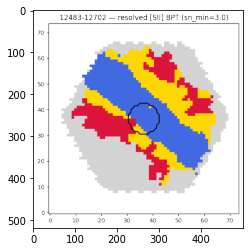

In [107]:
idx = 26
row = df.iloc[idx]
print(row['plateifu'])
print(row['sn3_lier05_class'])
print(row['sn3_lier05_has_sy_annulus'])
profile = json.loads(row['baseline_radial_profile']) if type(row['baseline_radial_profile']) == str else None

print(profile)
img = plt.imread(df['bpt_figure_path'][idx])

plt.imshow(img)